<a href="https://colab.research.google.com/github/SXTXRN/Predictive_Maintenance/blob/main/65160138_PDMaintenance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import os
import glob
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. เชื่อมต่อกับ Google Drive
drive.mount('/content/drive')

# 2. กำหนด Path ของโฟลเดอร์ที่เก็บไฟล์ .txt (แก้ path ให้ตรงกับของคุณ)
# เช่น '/content/drive/MyDrive/my_data_folder'
folder_path = '/content/drive/MyDrive/Predictive_Maintenance/data'

# 3. ฟังก์ชันสำหรับอ่านและแปลงข้อมูลจากไฟล์ Text (คงเดิม)
def parse_vibration_file(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    equipment_name = "Unknown"
    start_idx = 0

    for i, line in enumerate(lines):
        if "Equipment:" in line:
            equipment_name = line.split("Equipment:")[1].strip()
        if line.strip().startswith("---------"):
            start_idx = i + 1
            break

    amplitudes = []
    for line in lines[start_idx:]:
        parts = line.split()
        if not parts or "Time" in parts:
            continue
        for i in range(1, len(parts), 2):
            try:
                amplitudes.append(float(parts[i]))
            except ValueError:
                pass

    return equipment_name, np.array(amplitudes)

# 4. ฟังก์ชันสกัดฟีเจอร์ (คงเดิม)
def extract_features(amplitudes):
    if len(amplitudes) == 0: return None
    return {
        'mean': np.mean(amplitudes),
        'std': np.std(amplitudes),
        'max': np.max(amplitudes),
        'min': np.min(amplitudes),
        'rms': np.sqrt(np.mean(amplitudes**2)),
        'peak_to_peak': np.max(amplitudes) - np.min(amplitudes)
    }

# 5. วนลูปอ่านไฟล์ทุกไฟล์ในโฟลเดอร์ Google Drive
data_records = []
file_pattern = os.path.join(folder_path, "*.txt")
file_list = glob.glob(file_pattern)

if not file_list:
    print(f"ไม่พบไฟล์ .txt ใน path: {folder_path} กรุณาตรวจสอบชื่อโฟลเดอร์")
else:
    for file_path in file_list:
        equipment, amps = parse_vibration_file(file_path)
        features = extract_features(amps)
        if features is not None:
            features['equipment_type'] = equipment
            data_records.append(features)

    # 6. สร้างโมเดล
    df = pd.DataFrame(data_records)
    X = df.drop('equipment_type', axis=1)
    y = df['equipment_type']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # 7. แสดงผล
    y_pred = model.predict(X_test)
    print(f"อ่านไฟล์สำเร็จทั้งหมด: {len(file_list)} ไฟล์")
    print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
อ่านไฟล์สำเร็จทั้งหมด: 9 ไฟล์
Accuracy: 50.00%

Classification Report:
                                precision    recall  f1-score   support

(CHPP) Cooling Pump for OAH-02       0.00      0.00      0.00         0
                   Jockey Pump       1.00      0.50      0.67         2

                      accuracy                           0.50         2
                     macro avg       0.50      0.25      0.33         2
                  weighted avg       1.00      0.50      0.67         2



In [6]:
import numpy as np
import pandas as pd
import os
import glob
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Mount Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. ระบุ Path ให้ตรงกับโครงสร้างที่คุณแจ้ง (Predictive_Maintenance/data)
# หมายเหตุ: ตรวจสอบตัวพิมพ์เล็ก-ใหญ่ ของชื่อโฟลเดอร์ให้ตรงกับใน Drive จริงๆ นะครับ
folder_path = '/content/drive/MyDrive/Predictive_Maintenance/data'

# ใช้ glob ค้นหาไฟล์ .txt ทั้งหมดในโฟลเดอร์นั้น
txt_files = glob.glob(os.path.join(folder_path, "*.txt"))

if len(txt_files) > 0:
    print(f"✅ สำเร็จ! พบไฟล์ข้อมูล .txt ทั้งหมด {len(txt_files)} ไฟล์ ในโฟลเดอร์ data")

    data_records = []

    def parse_vibration_file(file_path):
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            lines = f.readlines()

        equipment_name = "Unknown"
        start_idx = 0
        for i, line in enumerate(lines):
            if "Equipment:" in line:
                raw_name = line.split("Equipment:")[1].strip()
                # ล้างชื่อให้เหลือแค่ประเภทเครื่องจักรหลัก
                equipment_name = raw_name.replace("(CHPP) ", "").split(" for ")[0].strip()
            if "---------" in line:
                start_idx = i + 1
                break

        amplitudes = []
        for line in lines[start_idx:]:
            parts = line.split()
            if not parts or "Time" in parts: continue
            for i in range(1, len(parts), 2):
                try: amplitudes.append(float(parts[i]))
                except: pass
        return equipment_name, np.array(amplitudes)

    def extract_features(amps):
        if len(amps) == 0: return None
        return {
            'mean': np.mean(amps),
            'std': np.std(amps),
            'max': np.max(amps),
            'min': np.min(amps),
            'rms': np.sqrt(np.mean(amps**2)),
            'p2p': np.max(amps) - np.min(amps)
        }

    # อ่านข้อมูลจากทุกไฟล์
    for full_p in txt_files:
        eq, amps = parse_vibration_file(full_p)
        feat = extract_features(amps)
        if feat:
            feat['target'] = eq
            data_records.append(feat)

    # 3. สร้าง DataFrame และเทรนโมเดล
    df = pd.DataFrame(data_records)
    X = df.drop('target', axis=1)
    y = df['target']

    # แบ่งข้อมูล Train/Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    print("\n" + "="*40)
    print("📊 รายงานผลการวิเคราะห์ (Classification Report)")
    print("="*40)
    print(classification_report(y_test, model.predict(X_test)))

else:
    print(f"❌ ยังหาไฟล์ไม่เจอใน: {folder_path}")
    print("สิ่งที่พบในโฟลเดอร์นี้คือ:", os.listdir(folder_path) if os.path.exists(folder_path) else "ไม่พบโฟลเดอร์นี้เลย")

✅ สำเร็จ! พบไฟล์ข้อมูล .txt ทั้งหมด 9 ไฟล์ ในโฟลเดอร์ data

📊 รายงานผลการวิเคราะห์ (Classification Report)
              precision    recall  f1-score   support

Cooling Pump       0.00      0.00      0.00         0
 Jockey Pump       1.00      0.50      0.67         2

    accuracy                           0.50         2
   macro avg       0.50      0.25      0.33         2
weighted avg       1.00      0.50      0.67         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [7]:
import numpy as np
import pandas as pd
import os
import glob
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Mount Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/Predictive_Maintenance/data'
txt_files = glob.glob(os.path.join(folder_path, "*.txt"))

def parse_vibration_file(file_path):
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    equipment_name = "Unknown"
    start_idx = 0
    for i, line in enumerate(lines):
        if "Equipment:" in line:
            raw_name = line.split("Equipment:")[1].strip()
            # จัดกลุ่มชื่อเครื่องจักรให้ชัดเจน
            if "Cooling Pump" in raw_name: equipment_name = "Cooling Pump"
            elif "Jockey Pump" in raw_name: equipment_name = "Jockey Pump"
            elif "Motor Compressor" in raw_name: equipment_name = "Motor Compressor"
            else: equipment_name = raw_name

        if "---------" in line:
            start_idx = i + 1
            break

    amplitudes = []
    for line in lines[start_idx:]:
        parts = line.split()
        if not parts or "Time" in parts: continue
        for i in range(1, len(parts), 2):
            try: amplitudes.append(float(parts[i]))
            except: pass
    return equipment_name, np.array(amplitudes)

def extract_features(amps):
    return {
        'mean': np.mean(amps), 'std': np.std(amps),
        'max': np.max(amps), 'min': np.min(amps),
        'rms': np.sqrt(np.mean(amps**2)),
        'p2p': np.max(amps) - np.min(amps)
    }

# --- ส่วนสำคัญ: ตัดแบ่งข้อมูลเป็นหน้าต่างย่อย (Windowing) ---
window_size = 500  # ทุกๆ 500 จุดนับเป็น 1 ข้อมูลใหม่
data_records = []

for full_p in txt_files:
    eq, amps = parse_vibration_file(full_p)
    if len(amps) > window_size:
        # ตัดแบ่งเป็นส่วนๆ
        for i in range(0, len(amps) - window_size, window_size):
            window_amps = amps[i : i + window_size]
            feat = extract_features(window_amps)
            feat['target'] = eq
            data_records.append(feat)

df = pd.DataFrame(data_records)

if not df.empty:
    X = df.drop('target', axis=1)
    y = df['target']

    # ใช้ stratify=y เพื่อให้ทั้ง Train และ Test มีครบทุกเครื่องจักร
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    print(f"✅ ข้อมูลเพิ่มขึ้นเป็น: {len(df)} samples (จากเดิม 9 ไฟล์)")
    print("\n" + "="*45)
    print("📊 ผลการวิเคราะห์ใหม่ (หลังทำ Windowing)")
    print("="*45)
    print(classification_report(y_test, model.predict(X_test)))
else:
    print("ไม่สามารถสร้างข้อมูลได้ กรุณาเช็คจำนวนจุดข้อมูลในไฟล์")

✅ ข้อมูลเพิ่มขึ้นเป็น: 100 samples (จากเดิม 9 ไฟล์)

📊 ผลการวิเคราะห์ใหม่ (หลังทำ Windowing)
                  precision    recall  f1-score   support

    Cooling Pump       0.89      1.00      0.94        17
     Jockey Pump       1.00      0.50      0.67         4
Motor Compressor       1.00      1.00      1.00         9

        accuracy                           0.93        30
       macro avg       0.96      0.83      0.87        30
    weighted avg       0.94      0.93      0.92        30



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, 

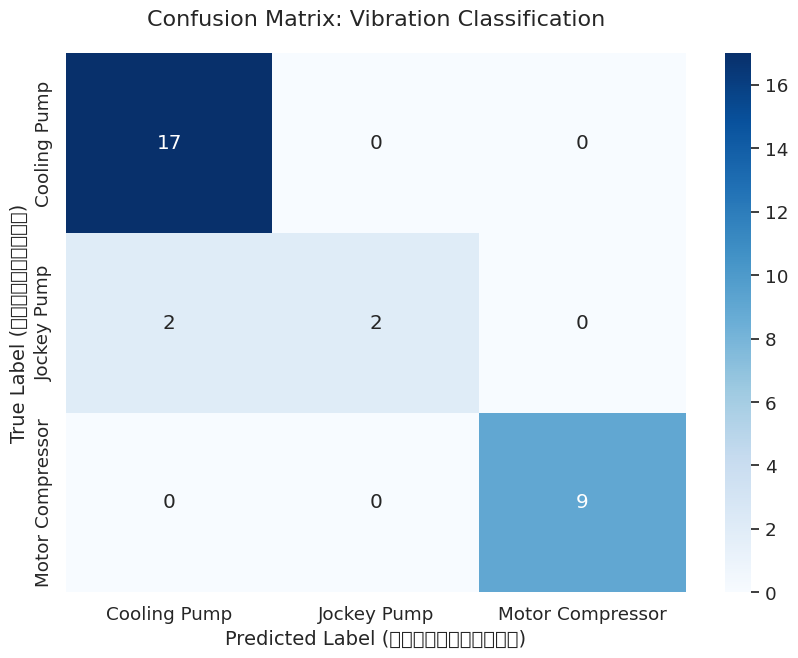

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. สร้าง Confusion Matrix จากค่าจริง (y_test) และค่าที่โมเดลทาย (y_pred)
y_pred = model.predict(X_test)
labels = sorted(y.unique()) # ดึงชื่อคลาสมาเรียงลำดับ
cm = confusion_matrix(y_test, y_pred, labels=labels)

# 2. ตั้งค่ารูปภาพ
plt.figure(figsize=(10, 7))
sns.set(font_scale=1.2) # ปรับขนาดตัวอักษร

# 3. วาด Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

# 4. ตกแต่งกราฟ
plt.title('Confusion Matrix: Vibration Classification', pad=20, fontsize=16)
plt.xlabel('Predicted Label (โมเดลทายว่า)', fontsize=14)
plt.ylabel('True Label (ค่าจริงคือ)', fontsize=14)
plt.show()

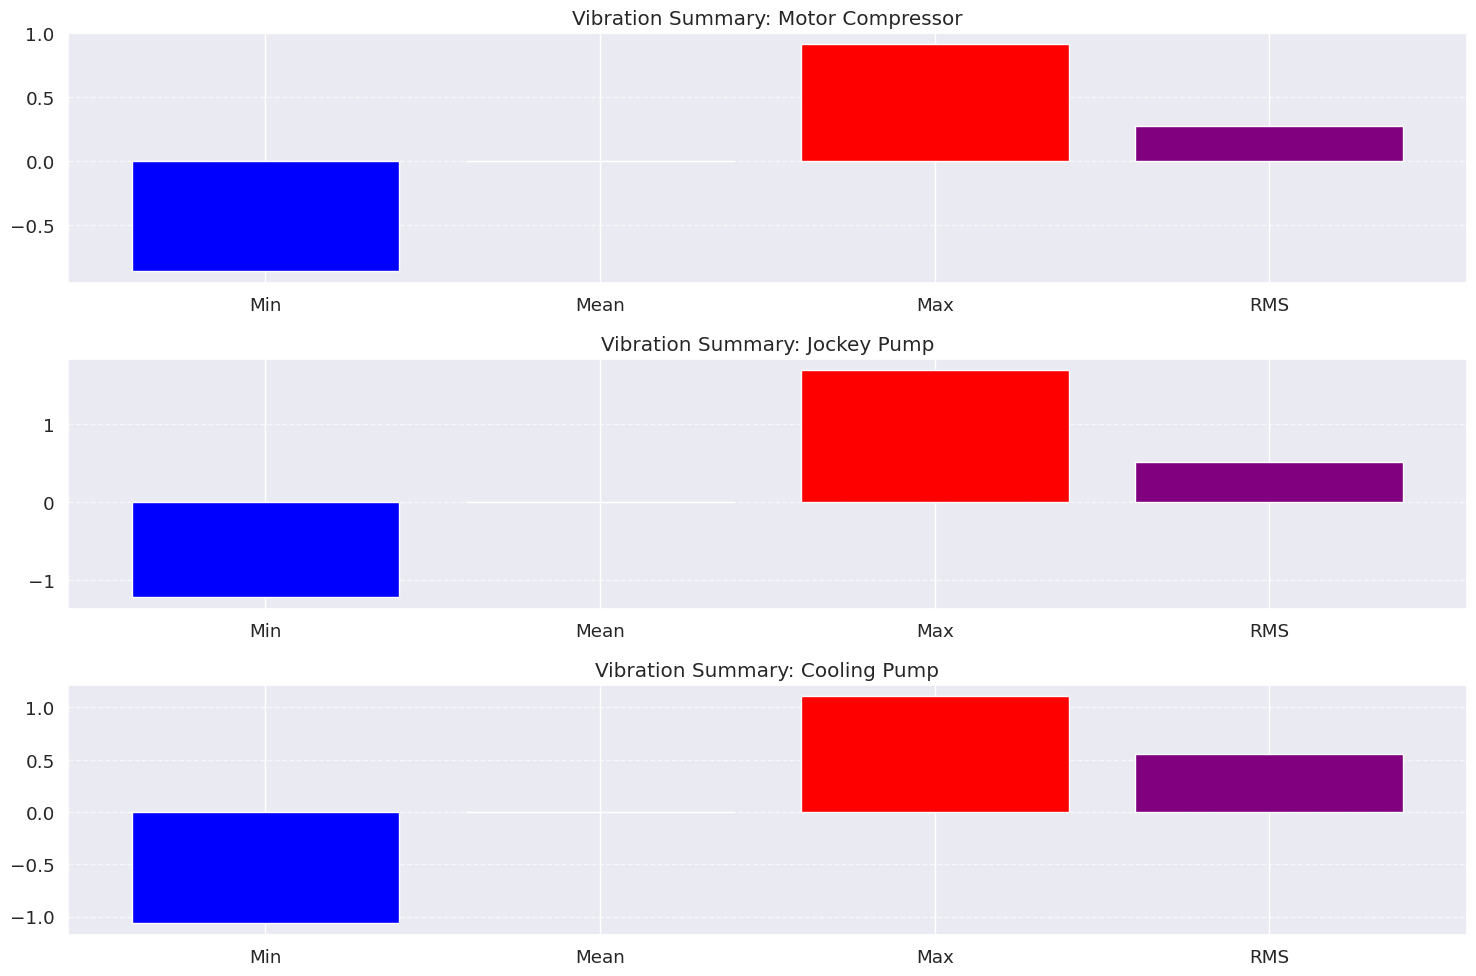

In [9]:
import matplotlib.pyplot as plt

# เลือกตัวอย่างสัญญาณจากแต่ละเครื่องจักรมาอย่างละ 1 ตัวอย่าง
unique_equip = df['target'].unique()
plt.figure(figsize=(15, 10))

for i, equip in enumerate(unique_equip):
    # ดึงข้อมูลจาก DataFrame ที่เราทำ Windowing ไว้แล้ว
    sample_signal = df[df['target'] == equip].iloc[0]

    plt.subplot(len(unique_equip), 1, i+1)
    # ในที่นี้เราอาจจะพลอตค่าสถิติ หรือถ้าเก็บค่า raw ไว้ก็นำมาพลอตได้
    # สมมติแสดงเป็นช่วงของแรงสั่นสะเทือน (Min-Max)
    plt.bar(['Min', 'Mean', 'Max', 'RMS'],
            [sample_signal['min'], sample_signal['mean'], sample_signal['max'], sample_signal['rms']],
            color=['blue', 'green', 'red', 'purple'])
    plt.title(f'Vibration Summary: {equip}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

/tmp/ipykernel_474/1096749994.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=feature, data=df, palette='Set2')
/tmp/ipykernel_474/1096749994.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=feature, data=df, palette='Set2')
/tmp/ipykernel_474/1096749994.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=feature, data=df, palette='Set2')


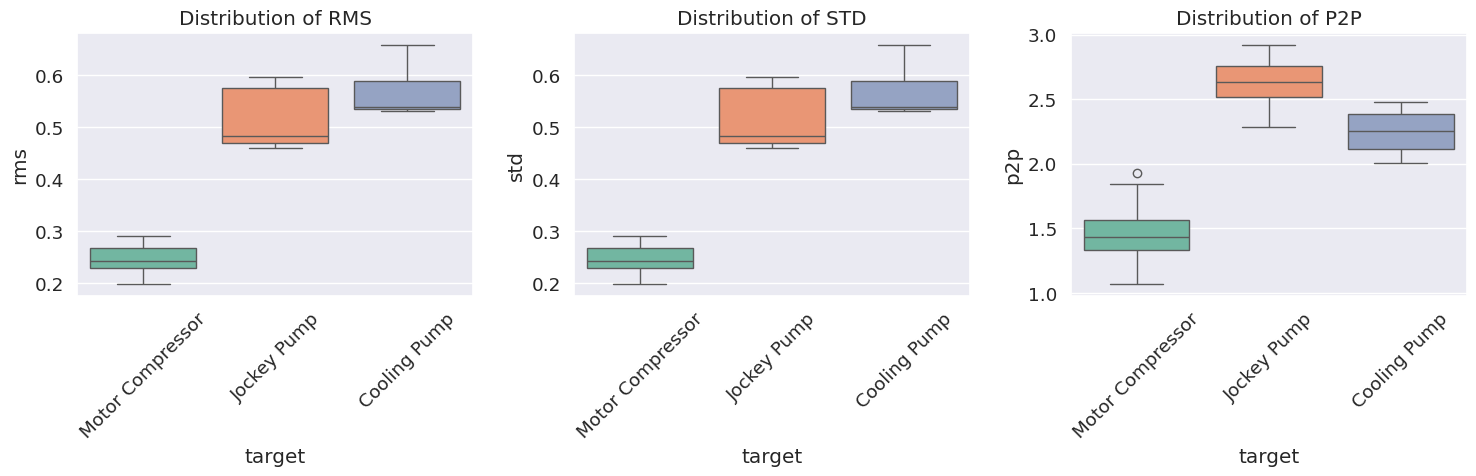

In [10]:
import seaborn as sns

# เลือกฟีเจอร์หลักๆ มาดูการกระจายตัว
features_to_plot = ['rms', 'std', 'p2p']
plt.figure(figsize=(15, 5))

for i, feature in enumerate(features_to_plot):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='target', y=feature, data=df, palette='Set2')
    plt.title(f'Distribution of {feature.upper()}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()